In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats, optimize, special

## Part A: Maternal Smoking

#### Pre-processing

In [2]:
smoke_df = pd.read_csv('/Users/kevinkinsey/IITM/EE3111/lab2/data/babiesI.data', sep=r'\s+')
smoke_df.head()

,bwt,smoke
0,120,0
1,113,0
2,128,1
3,123,0
4,108,1


In [3]:
print(f"No of smokers: {(smoke_df['smoke'] == 1).sum()} / {len(smoke_df['smoke'])} | {(smoke_df['smoke'] == 1).sum() * 100 / len(smoke_df['smoke']):.2f}%")
print(f"Missing values before cleaning:\n{smoke_df.isnull().sum()}")

No of smokers: 484 / 1236 | 39.16%
Missing values before cleaning:
bwt      0
smoke    0
dtype: int64


In [4]:
print(f"Unique values for smoking: {smoke_df['smoke'].nunique()}")
print("Values:", smoke_df['smoke'].unique())

Unique values for smoking: 3
Values: [0 1 9]


In [5]:
smoke_df = smoke_df[smoke_df['smoke'] != 9]

In [6]:
print(f"Unique values for smoking: {smoke_df['smoke'].nunique()}")
print("Values:", smoke_df['smoke'].unique())

Unique values for smoking: 2
Values: [0 1]


#### Visual Comparison

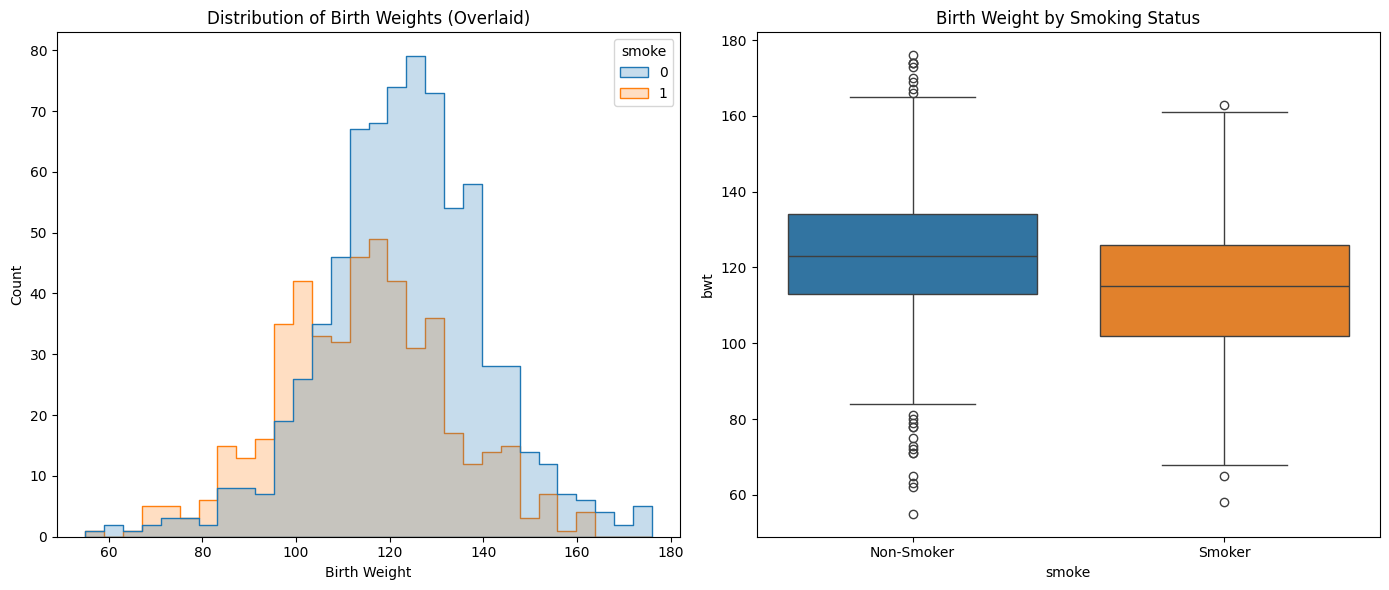

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Histograms
# (No changes needed here, but included for completeness)
sns.histplot(data=smoke_df, x='bwt', hue='smoke', kde=False, element="step", ax=ax[0], palette="tab10")
ax[0].set_title("Distribution of Birth Weights (Overlaid)")
ax[0].set_xlabel("Birth Weight")

# Plot 2: Boxplot (Fixes applied)
# Fix 1: Added `hue='smoke'` and `legend=False` to satisfy the new palette requirement
sns.boxplot(data=smoke_df, x='smoke', y='bwt', hue='smoke', legend=False, ax=ax[1], palette="tab10")

ax[1].set_title("Birth Weight by Smoking Status")

# Fix 2: Explicitly set tick positions before setting labels to silence UserWarning
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Non-Smoker', 'Smoker'])

plt.tight_layout()
plt.show()

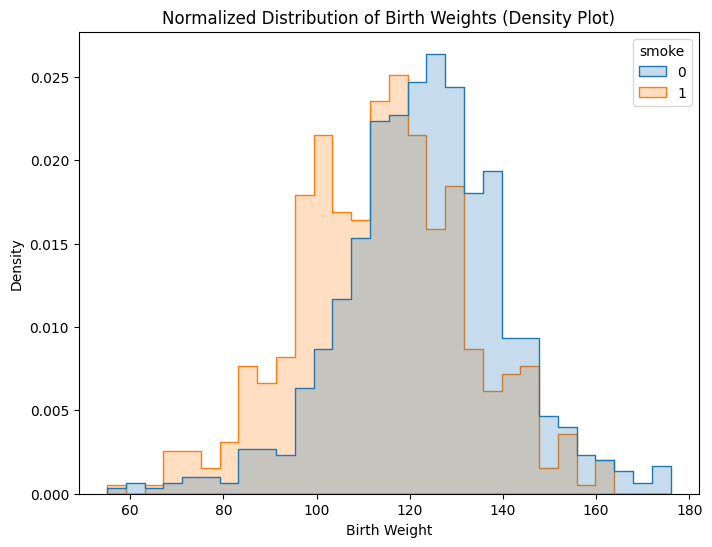

In [8]:
plt.figure(figsize=(8, 6))

# 'stat="density"' normalizes the y-axis
# 'common_norm=False' ensures each group is normalized independently (area of each = 1)
sns.histplot(
    data=smoke_df, 
    x='bwt', 
    hue='smoke', 
    stat="density",      # Normalize counts to density
    common_norm=False,   # Normalize each group separately
    element="step", 
    palette="tab10"
)

plt.title("Normalized Distribution of Birth Weights (Density Plot)")
plt.xlabel("Birth Weight")
plt.ylabel("Density")
plt.show()

In [9]:
smstats = smoke_df.groupby('smoke')['bwt'].agg(['mean', 'median', 'std', 'skew', 'kurt'])
smstats.index = ['Non-Smoker', 'Smoker']

smstats

,mean,median,std,skew,kurt
Non-Smoker,123.047170,123.0,17.398689,-0.187363,1.052213
Smoker,114.109504,115.0,18.098946,-0.033700,0.000408


#### Analysis:
Maternal smoking appears to be associated with lower birth weights.
There is a clear downward shift in weight. The mean birth weight for smokers (114.11) is approximately 9 units lower than for non-smokers (123.05), and the median reflects a similar decrease (115 vs. 123).

Variance analysis

The Std is slightly higher for Smokers (18.10) compared to Non-Smokers (17.40).
This could be attributed to the fact that the extent of smoking in unknown causing more variability in the data.

Looking skew and kurtosis

The Non-Smoker data has a "sharper" peak and "fatter" tails than a normal distribution. This suggests there are more extreme values (outliers) in the non-smoker group compared to the smoker group, which follows a classic bell curve shape.

#### In class Component

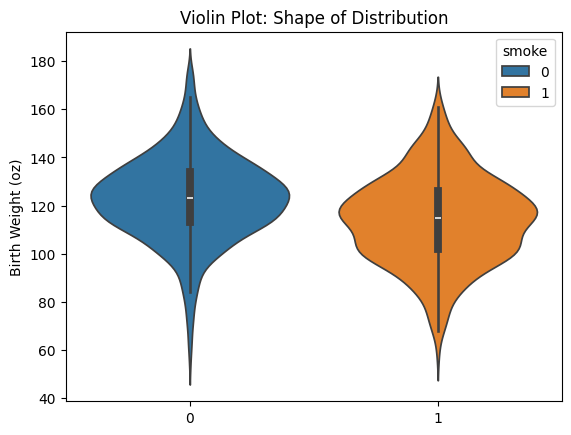

In [10]:
sns.violinplot(x=smoke_df['smoke'], y=smoke_df['bwt'], hue=smoke_df['smoke'])
plt.title('Violin Plot: Shape of Distribution')
plt.ylabel('Birth Weight (oz)')
plt.xlabel('')
plt.show()

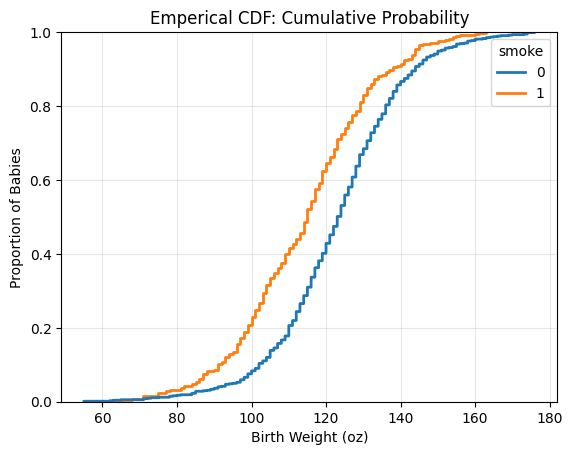

In [11]:
sns.ecdfplot(data=smoke_df, x=smoke_df['bwt'], hue=smoke_df['smoke'], linewidth=2)
plt.title('Emperical CDF: Cumulative Probability')
plt.ylabel('Proportion of Babies')
plt.xlabel('Birth Weight (oz)')
plt.grid(True, alpha=0.3)
plt.show()

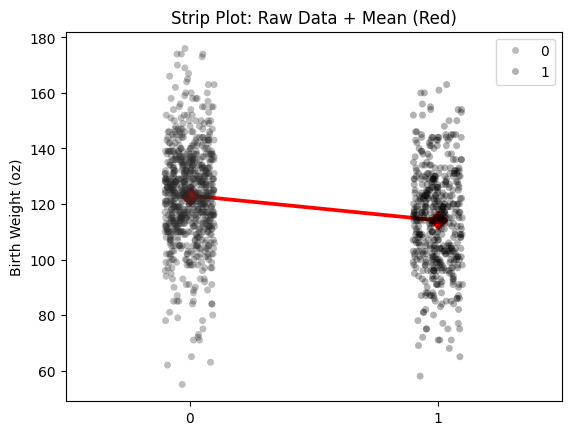

In [12]:
sns.stripplot(data=smoke_df, x='smoke', y='bwt', hue='smoke', palette="dark:black", alpha=0.3, jitter=True)
sns.pointplot(data=smoke_df, x='smoke', y='bwt', color='red', markers='D', markersize=8, errorbar='ci')
plt.title('Strip Plot: Raw Data + Mean (Red)')
plt.ylabel('Birth Weight (oz)')
plt.xlabel('')
plt.show()

## Part B: Video Game Analytics

In [13]:
vdf = pd.read_csv('/Users/kevinkinsey/IITM/EE3111/lab2/data/video.data', sep=r'\s+')
vdf.head()

,time,like,where,freq,busy,educ,sex,age,home,math,work,own,cdrom,email,grade
0,2.0,3,3,2,0,1,0,19,1,0,10,1,0,1,4
1,0.0,3,3,3,0,0,0,18,1,1,0,1,1,1,2
2,0.0,3,1,3,0,0,1,19,1,0,0,1,0,1,3
3,0.5,3,3,3,0,1,0,19,1,0,0,1,0,1,3
4,0.0,3,3,4,0,1,0,19,1,1,0,0,0,1,3


In [14]:
gmdf = vdf[vdf['time'] > 0]
print("No of gamers:", len(gmdf))
gmdf.head()

No of gamers: 34


,time,like,where,freq,busy,educ,sex,age,home,math,work,own,cdrom,email,grade
0,2.0,3,3,2,0,1,0,19,1,0,10,1,0,1,4
3,0.5,3,3,3,0,1,0,19,1,0,0,1,0,1,3
8,2.0,3,2,1,1,1,1,19,0,0,0,0,0,0,4
13,3.0,3,3,2,1,0,0,18,0,0,0,0,0,1,3
14,1.0,3,5,2,0,1,0,18,1,1,14,1,0,1,3


In [15]:
time_xi = gmdf['time'].to_numpy()

### Method of Moments

In [16]:
xm = time_xi.mean()
x2m = (time_xi ** 2).mean()

In [17]:
alpha_mom = xm**2 / (x2m - xm**2)
beta_mom = xm / (x2m - xm**2)

alpha_mom, beta_mom = map(float, (alpha_mom, beta_mom))
alpha_mom, beta_mom

(0.358894195090979, 0.1078903857921599)

### MLE

In [18]:
def neg_log_likelihood(params, data):
    alpha, beta = params
    if alpha <= 0 or beta <= 0:
        return np.inf

    n = len(data)
    log_likelihood = (
        n * alpha * np.log(beta)
        - n * special.gammaln(alpha)
        + (alpha - 1) * np.sum(np.log(data))
        - beta * np.sum(data)
    )
    
    return -log_likelihood

optm_results = optimize.minimize(
    neg_log_likelihood, 
    [alpha_mom, beta_mom], 
    args=(time_xi,), 
    method='L-BFGS-B', 
    bounds=((1e-5, None), (1e-5, None))
)

alpha_mle, beta_mle = map(float, optm_results.x)
alpha_mle, beta_mle

(0.919774386148841, 0.27650205579757076)

### Scipy

In [19]:
alpha_spy, loc_spy, scale_spy = stats.gamma.fit(time_xi, floc=0)
beta_spy = 1 / scale_spy

alpha_spy, beta_spy = map(float, (alpha_spy, beta_spy))
alpha_spy, beta_spy

(0.9197581039857808, 0.27649668908502695)

### Histo plots

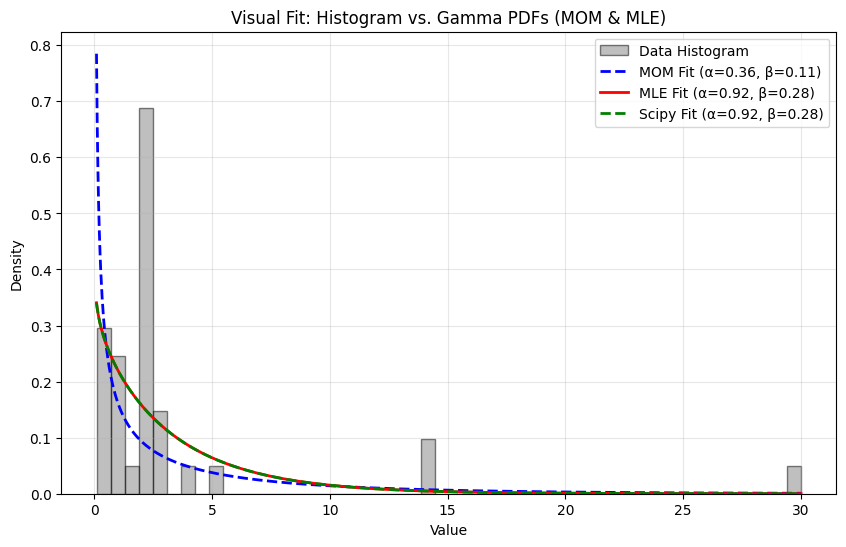

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(time_xi, bins=50, density=True, alpha=0.5, color='gray', label='Data Histogram', edgecolor='black')
x_vals = np.linspace(min(time_xi), max(time_xi), 1000)

pdf_mom = stats.gamma.pdf(x_vals, a=alpha_mom, scale=1/beta_mom)
plt.plot(x_vals, pdf_mom, 'b--', linewidth=2, label=f'MOM Fit (α={alpha_mom:.2f}, β={beta_mom:.2f})')

pdf_mle = stats.gamma.pdf(x_vals, a=alpha_mle, scale=1/beta_mle)
plt.plot(x_vals, pdf_mle, 'r-', linewidth=2, label=f'MLE Fit (α={alpha_mle:.2f}, β={beta_mle:.2f})')

pdf_spy = stats.gamma.pdf(x_vals, a=alpha_spy, scale=1/beta_spy)
plt.plot(x_vals, pdf_spy, 'g--', linewidth=2, label=f'Scipy Fit (α={alpha_spy:.2f}, β={beta_spy:.2f})')

plt.title('Visual Fit: Histogram vs. Gamma PDFs (MOM & MLE)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

##### Analysis
(For MOM v MLE)
- Bias for both -> O(1/n)
- Variance for both -> O(1/n)

MOM uses only 2 eq, MLE gives a better fit by minimising KL divergence

#### In class

In [21]:
print("MOM log Like:", - neg_log_likelihood((alpha_mom, beta_mom), time_xi))
print("MLE log Like:",  - neg_log_likelihood((alpha_mle, beta_mle), time_xi))

MOM log Like: -82.64338676652717
MLE log Like: -74.78531788012218


In [22]:
print("arbitrary log Like:",  - neg_log_likelihood((0.5, 0.4), time_xi))

arbitrary log Like: -89.93339341160275


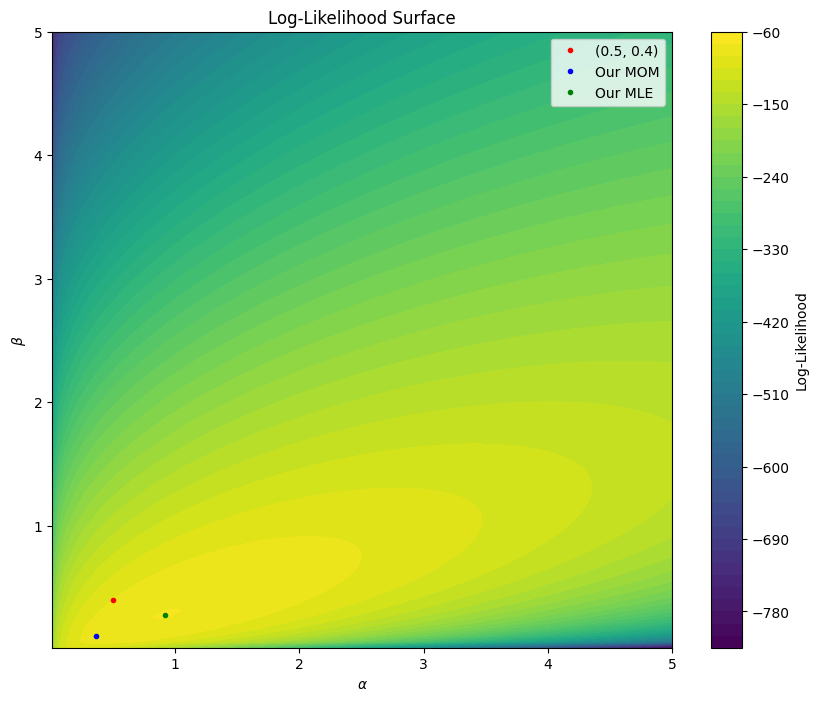

In [53]:
alpha_range = np.linspace(0.01, 5, 100)
beta_range = np.linspace(0.01, 5, 100)

P1, P2 = np.meshgrid(alpha_range, beta_range)
Z = np.array([[-neg_log_likelihood((p1, p2), time_xi) for p1 in alpha_range] for p2 in beta_range])

plt.figure(figsize=(10, 8))
cp = plt.contourf(P1, P2, Z, levels=50, cmap='viridis')
plt.colorbar(cp, label='Log-Likelihood')

plt.plot(0.5, 0.4, 'ro', markersize=3, label='(0.5, 0.4)')
plt.plot(alpha_mom, beta_mom, 'bo', markersize=3, label='Our MOM')
plt.plot(alpha_mle, beta_mle, 'go', markersize=3, label='Our MLE')
# plt.plot(alpha_spy, beta_spy, 'mo', markersize=3, label='Scipy')

plt.xlabel('$\\alpha$')
plt.ylabel('$\\beta$')
plt.title('Log-Likelihood Surface')
plt.legend()
plt.show()

In [34]:
def ks_distance(params, data):
    alpha, beta = params
    if alpha <= 0 or beta <= 0:
        return np.inf

    n = len(data)

    sorted_data = np.sort(data)
    i = np.arange(1, n + 1)
    ecdf_upper = i / n
    ecdf_lower = (i - 1) / n

    theoretical_cdf = stats.gamma.cdf(sorted_data, a=alpha, scale=beta)

    d_plus = np.abs(ecdf_upper - theoretical_cdf)
    d_minus = np.abs(theoretical_cdf - ecdf_lower)
    ks_statistic = np.max(np.maximum(d_plus, d_minus))
    
    return ks_statistic

In [58]:
temp = lambda a, b, c: stats.kstest(c, 'gamma', args=(a, 0, b))[0]
ks_distance((alpha_mle, beta_mle), time_xi), temp(alpha_mle, beta_mle, time_xi)

(np.float64(0.8266913050195369), np.float64(0.8266913050195369))

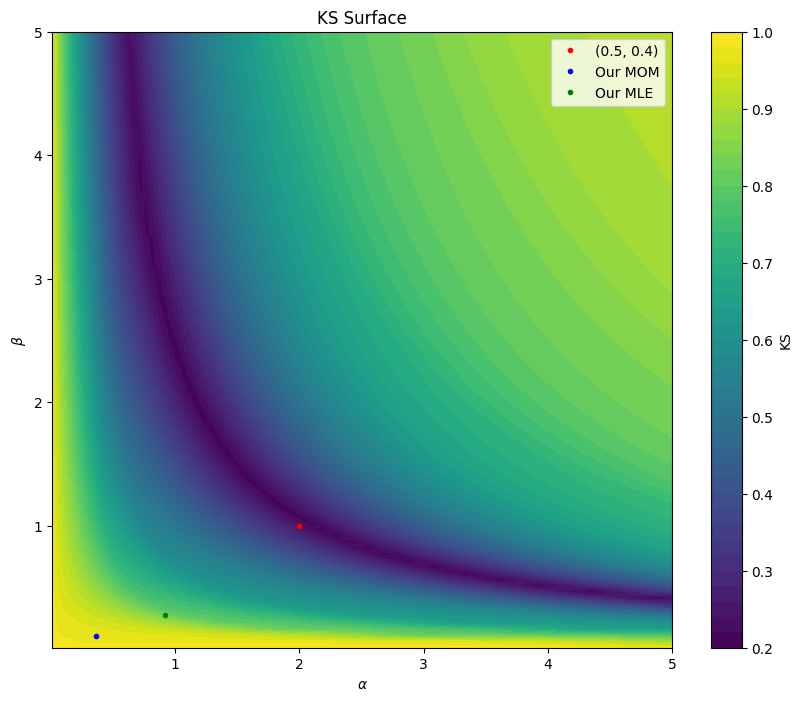

In [65]:
alpha_range = np.linspace(0.01, 5, 100)
beta_range = np.linspace(0.01, 5, 100)

P1, P2 = np.meshgrid(alpha_range, beta_range)
Z = np.array([[ks_distance((p1, p2), time_xi) for p1 in alpha_range] for p2 in beta_range])
# temp = lambda a, b, c: stats.kstest(c, 'gamma', args=(a, 0, b))[0]
# Z = np.array([[temp(p1, p2, time_xi) for p1 in alpha_range] for p2 in beta_range])

plt.figure(figsize=(10, 8))
cp = plt.contourf(P1, P2, Z, levels=50, cmap='viridis')
plt.colorbar(cp, label='KS')

plt.plot(2, 1, 'ro', markersize=3, label='(0.5, 0.4)')
plt.plot(alpha_mom, beta_mom, 'bo', markersize=3, label='Our MOM')
plt.plot(alpha_mle, beta_mle, 'go', markersize=3, label='Our MLE')

plt.xlabel('$\\alpha$')
plt.ylabel('$\\beta$')
plt.title('KS Surface')
plt.legend()

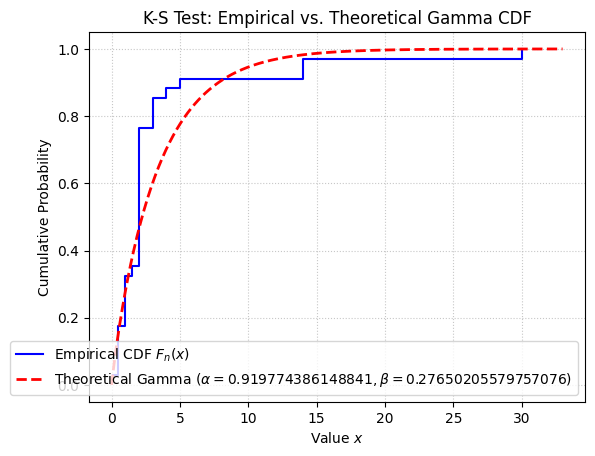

In [63]:
def plot_ks_comparison(data, alpha, beta):
    # Sort data for the Empirical CDF
    sorted_data = np.sort(data)
    n = len(data)
    ecdf_y = np.arange(1, n + 1) / n
    
    # Generate smooth x-axis for the Theoretical Gamma CDF
    x_theoretical = np.linspace(0, np.max(data) * 1.1, 500)
    theoretical_cdf = stats.gamma.cdf(x_theoretical, a=alpha, scale=1/beta)
    
    # Plotting
    plt.step(sorted_data, ecdf_y, where='post', label=r'Empirical CDF $F_n(x)$', color='blue')
    plt.plot(x_theoretical, theoretical_cdf, label=fr'Theoretical Gamma ($\alpha={alpha}, \beta={beta}$)', 
             color='red', linestyle='--', linewidth=2)
    
    plt.title('K-S Test: Empirical vs. Theoretical Gamma CDF')
    plt.xlabel('Value $x$')
    plt.ylabel('Cumulative Probability')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()


plot_ks_comparison(time_xi, alpha_mle, beta_mle)

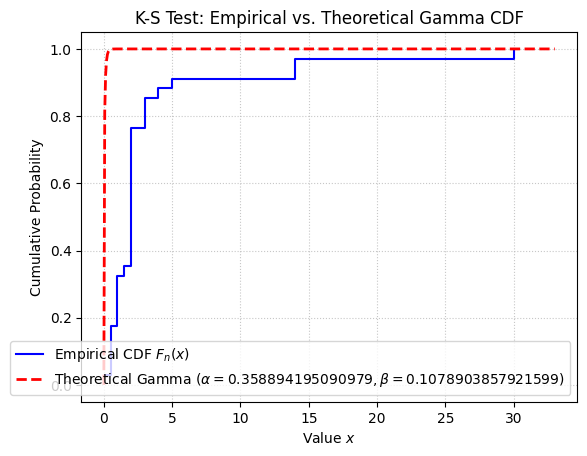

In [44]:
plot_ks_comparison(time_xi, alpha_mom, beta_mom)

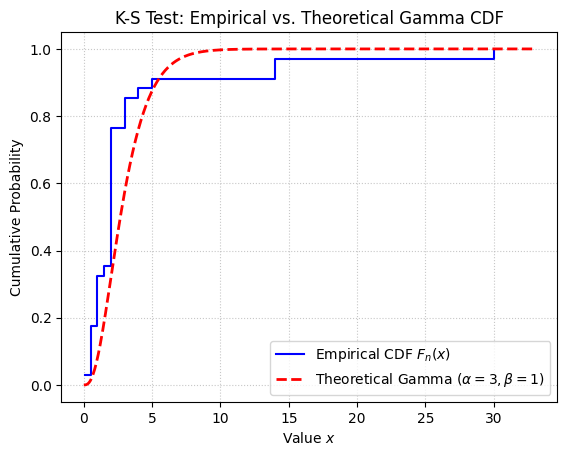

In [51]:
plot_ks_comparison(time_xi, 3, 1)

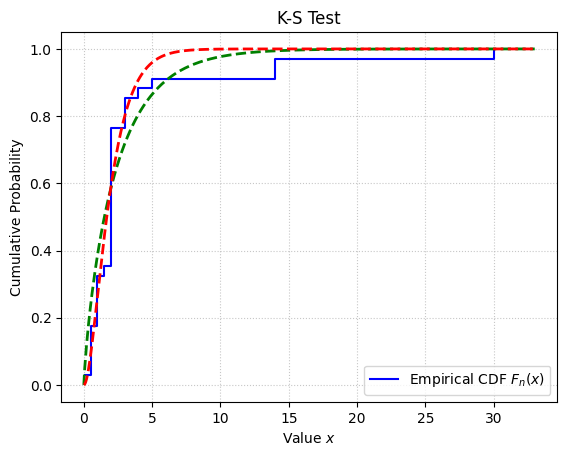

In [ ]:
sorted_data = np.sort(time_xi)
n = len(time_xi)
ecdf_y = np.arange(1, n + 1) / n

x_theoretical = np.linspace(0, np.max(time_xi) * 1.1, 500)

plt.step(sorted_data, ecdf_y, where='post', label=r'Empirical CDF $F_n(x)$', color='blue')
plt.plot(x_theoretical, stats.gamma.cdf(x_theoretical, a=0.8, scale=1/3), color='green', linestyle='--', linewidth=2)
plt.plot(x_theoretical, stats.gamma.cdf(x_theoretical, a=2, scale=1), color='red', linestyle='--', linewidth=2)

plt.title('K-S Test')
plt.xlabel('Value $x$')
plt.ylabel('Cumulative Probability')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()